# AP 155 Lab Exercise
---
## Exercise 5: Matrices

_Instructions_: 
- **Report figure:** Plot of voltage for each node. 
- **Report discussion:**
  - What were the basis linear equations used to set up the matrix in each question of Problem 2?
  - Once you set up the matrices, what function did you use to solve the matrix equation (Could have different answers)? Check the docstring/documentation/other references and summarize the mechanism behind the function 
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Abellana, Karl Gian
- _Student No._: 2024-09545
- _Section_: WX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

<!-- ### Report figure

<img src="figures/cat.jpg" alt="Alt text" width=45%> <img src="figures/cat.jpg" alt="Alt text" width=45%>


EDIT ME. See instruction above for what to include. Insert caption here, a short description what the figure illustrates. The syntax in markdown for putting a figure is `![Description](local_file_name.png)` or `<img src="/path/to_image.jpg" alt="Alt text" width=45%>`. Make sure the figure has complete elements.
-->

### Report discussion

<img src="reschain.png" alt="Alt text" width=95%>

To solve this system, we make use of matrices. Consider the equation $\bf{A}\vec{v} = \vec{w}$. 
$\bf{A}$ is our coefficient matrix corresponding to the coefficients for each voltage in the system of equations, while $\vec{w}$ is the vector that contains our known solution to each equation in the system. For a small matrix, we can use ```np.linalg.solve```, which uses an LU-decomposition algorithm to solve. This gets more inefficient for larger matrices, so a different algorithm was put into place for N = 10000 using ```banded.py()```.

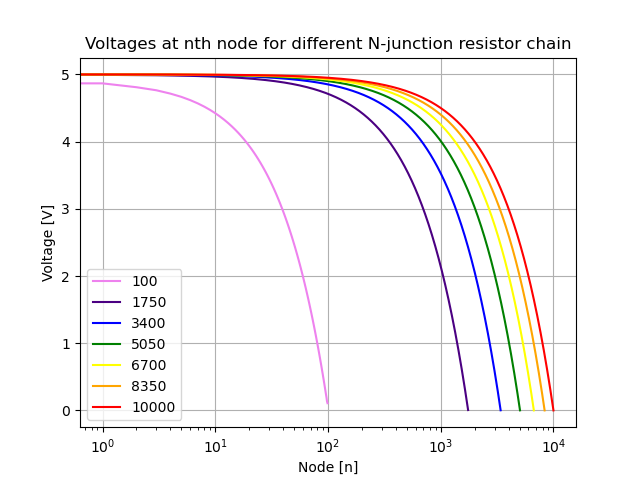

Observe that the voltage doesn't go over the source voltage (5V), and the voltage at some junction approaches 0 as it approaches the last junction. Observe that this range doesn't change at all no matter how many resistors we add in the chain. The only thing that changes the rate at which the voltage decays with respect to the junction, it will take longer for the voltage to approach 0 the more resistors are in the chain.

### Other comments
- EDIT ME
- A self reflection can be placed here.
- This portion is not graded.
- You may insert further questions here.


---
## Section 2: Code

### Problem 1: (Newman 6.7) Resistor Ladder

**READ THE INSTRUCTIONS COMPLETELY**

Consider a long chain of resistors wired up like this:

<img src="reschain.png" alt="Alt text" width=95%>

All the resistors have the same resistance $R$.  The power rail at the top is at voltage $V_+=5$V.  The problem is to find the voltages $V_1, \ldots, V_N$ at the internal nodes in the circuit.

1. **Using Ohm's law and the Kirchhoff current law**, which says that the total net current flow out of (or into) any junction in a circuit must be zero, show that the voltages $V_1\ldots V_N$ satisfy the equations

$$3V_1 - V_2 - V_3 = V_+ $$
$$-V_1 + 4V_2 - V_3 - V_4 = V_+ $$
$$\cdots$$
$$-V_{i-2} - V_{i-1} + 4V_i - V_{i+1} - V_{i+2} = 0 $$
$$\cdots$$
$$-V_{N-3} - V_{N-2} + 4V_{N-1} - V_N = V_- = 0 $$
$$-V_{N-2} - V_{N-1} + 3V_N = V_- = 0 $$

Note: The assignment of $V_-$ is to make the equations symmetric

2. Express these equations in vector form $A\vec{v} = \vec{w}$ and find the values of the matrix $A$ and the vector $\vec{w}$.

3. Write a program to solve for the values of the $V_i$ when there are $N=6$ internal junctions with unknown voltages. (Hint: All the values of $V_i$ should lie between zero and $5$V.  If they don't, something is wrong.)

4. Now repeat your calculation for the case where there are $N=10\,000$ internal junctions.  This part is not possible using standard tools like the `np.linalg.solve` function.  You need to make use of the fact that the matrix $\vec{A}$ is banded, and uses `banded.py` by Mark Newman which can be obtained from the link: https://public.websites.umich.edu/~mejn/cp/programs.html

5. Plot your voltages in a histogram, make different histograms for varying number of nodes

In [1]:
import numpy as np
import scipy.linalg as linalg
import banded as bnd
import matplotlib.pyplot as plt

In [2]:
# code here

# Creating system of N = 6
V = 5
N = 6

def createAandW(size, V):
    a_loc = (
        np.diag(np.ones(size)*4, k=0) # main diagonal mainly 4
        +np.diag(np.ones(size-1)*-1, k=-1) # lower diagonal of -1
        +np.diag(np.ones(size-1)*-1, k=1) # upper diagonal of -1
        +np.diag(np.ones(size-2)*-1, k=-2) # second lower diagonal of -1
        +np.diag(np.ones(size-2)*-1, k=2) # second upper diagonal of -1
    )
    a_loc[0,0], a_loc[size-1,size-1] = 3, 3 # the last diagonal elements are 3

    w_loc = np.zeros(size)
    w_loc[0], w_loc[1]= V, V # first two are of source voltage

    w_loc = w_loc.reshape(-1, 1) # make it a column vector

    return a_loc, w_loc

A, w = createAandW(N, V)

# now we find v using np.linalg.solve
v = np.linalg.solve(A,w)

print(f"v = \n{v}")

v = 
[[3.7254902 ]
 [3.43137255]
 [2.74509804]
 [2.25490196]
 [1.56862745]
 [1.2745098 ]]


Matrix has 5 rows


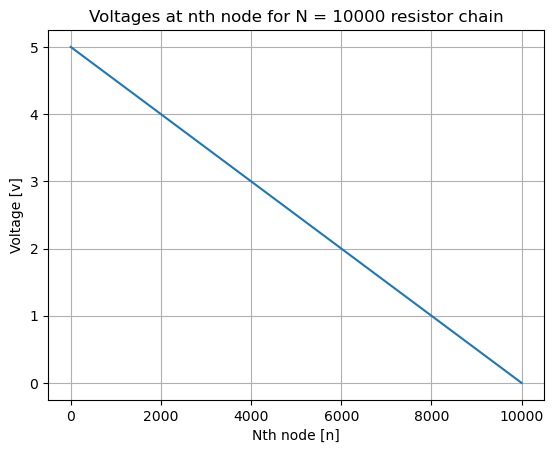

In [3]:
# Now for the case where there are N = 10000 internal junctions
V = 5
N = 10000
up = 2
down = 2

def createAandWbanded(size, V):
    # create the rows and then stack it

    # all the up and downs
    up_and_downs = np.ones(size)*-1
    # the diagonal
    diag = np.ones(size)*4

    # stack them up
    a_matrix = np.vstack([up_and_downs, up_and_downs, diag, up_and_downs, up_and_downs])

    # make sure that the row is size 1 + up + down = 1 + 2 + 2 = 5
    print(f"Matrix has {a_matrix[:, 0].size} rows")

    # fix the first two columns and last two columns:
    a_matrix[:, 0] = [0, 0, 3, -1, -1]
    a_matrix[:, 1] = [0, -1, 4, -1, -1]
    a_matrix[:, -1] = [-1, -1, 3, 0, 0]
    a_matrix[:, -2] = [-1, -1, 4, -1, 0]

    _, w_loc = createAandW(size, V)

    return a_matrix, w_loc

A_2, w_2 = createAandWbanded(N, V)

v_2 = bnd.banded(A_2, w_2, 2, 2)

plt.plot(v_2)
plt.xlabel("Nth node [n]")
plt.ylabel("Voltage [v]")
plt.grid()
plt.title("Voltages at nth node for N = 10000 resistor chain")
plt.savefig("n10000.png")
plt.show()

Matrix has 5 rows
Matrix has 5 rows
Matrix has 5 rows
Matrix has 5 rows
Matrix has 5 rows
Matrix has 5 rows
Matrix has 5 rows


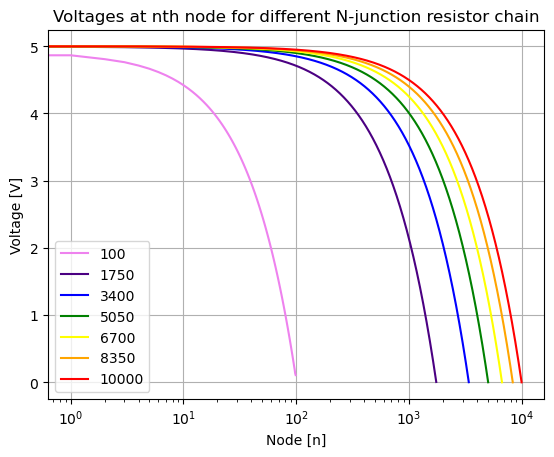

In [4]:
# set up initial variables, we do linspace for varying number of nodes
V = 5
ns = np.linspace(100, 10000, 7, endpoint=True).astype(int)

v_list = []
color_list = ["violet", "indigo", "blue", "green", "yellow", "orange", "red"] # make it rainbow

# we have to be careful here, explicitly write the for loop this time.
for n in ns:
    A_n, w_n = createAandWbanded(n,V)
    v = bnd.banded(A_n, w_n, 2, 2)
    v_list.append(v)

for k in range(len(ns)):
    plt.semilogx(v_list[k], label = ns[k], color = color_list[k])
plt.legend()
plt.grid()
plt.title("Voltages at nth node for different N-junction resistor chain")
plt.xlabel("Node [n]")
plt.ylabel("Voltage [V]")
plt.savefig("differentN.png")
plt.show()

#### Problem 1 code summary
---
We solved the resistor chain system of N-junctions by using numpy arrays and using ```np.linalg.solve()``` to find the solution $\vec{v}$, which corresponds to the voltages at the nth junction. It was conceptualized starting from N = 6, and then N = 10000. The large matrix had to be recasted into (up + down + 1) by n dimensions by taking note of the band pattern and making rows corresponding to each band, and then stacking them on top of each other using ```np.vstack()```. The ends of the matrices were fixed because thats where the pattern breaks, using ```[:, i]``` to rewrite the ith column of numpy array. This is because we are using ```banded.py()``` which requires a compact matrix input. It was then plotted using ```matplotlib``` in a log x scale to highlight how voltage goes from first node to last.

## Section 3 (Notes)

### Some codes for solving matrix problems

* solving matrix equations ($\bf{A}\vec{x} = \vec{b}$) -> `np.linalg.solve`
* LU-decomposition ($\bf{A} = \bf{L}\bf{U}$) -> `scipy.linalg.lu`
* matrix inversion ($\bf{A}^{-1}$) -> `np.linalg.inv`
* QR-decomposition ($\bf{A} = \bf{Q}\bf{R}$) -> `scipy.linalg.qr`
* eigenvalue problem ($\bf{A}\vec{x} = \lambda \vec{x}$) -> `np.linalg.eig`

Solving matrix problems by themselves isn't difficult. There is an abundance of linear algebra libraries that are ready to use: from the battle-tested ones (the classic [BLAS](https://www.netlib.org/blas/) and [LAPACK](https://www.netlib.org/lapack/)), HPC tools for large problems ([ScaLAPACK](https://netlib.org/scalapack/)), to hardware-accelerated ones often with GPUs ([cuBLAS](https://docs.nvidia.com/cuda/cublas/index.html) and [cuSolver](https://docs.nvidia.com/cuda/cusolver/index.html) for NVIDIA). 

The hardest part is actually composing the matrix. How do you transform a physical problem into a linear algebra problem?

* Circuit: https://personal.math.vt.edu/embree/cmda3606/chapter2.pdf
* Embree [main notes](https://personal.math.vt.edu/embree/cmda3606notes.pdf) + [lab manual](https://personal.math.vt.edu/embree/labman.pdf)

#### Sample Usage

### Importing functions from a python file